# Brain-age error analysis — best LaBraM fine-tune vs. the data

Where, and why, does the brain-age model make its errors? This notebook takes the best
short-schedule run (selected on **validation** case MAE) and examines its errors against the data:

1. **Training dynamics**: the train/val gap (memorization).
2. **Error summary**: window vs. recording level, mean vs. median, by cohort (normal / abnormal), including
   the train split scored in eval mode.
3. **Error and loss distributions**: per sample (window) and per recording, and the tails.
4. **Per-sample view**: spread of the window predictions inside a recording, mean vs. median pooling, and
   position in the recording.
5. **Regression to the mean**: error by age bin against the train sampling density (how over- or
   under-sampled each age is).
6. **Post-hoc bias correction**: fitted on val, applied to test.
7. **Normal vs. abnormal**, and the **spectral correlates** of the residual.
8. **Real EEG**: at the same true age, a recording predicted accurately vs. one predicted too young
   vs. one too old, side by side; the extreme cases; an **interactive explorer**; and a playground.
9. **Run comparison**: predicted vs. true age per decade across the other trained runs (mixup / C-Mixup / EMA / long /
   age-balanced loss).

Setup: scenario D (CAR input, Huber δ=1, lr 1e-4, layer decay 0.65), subject-disjoint split,
5-minute val/test budget per recording (30 × 10 s windows), 60 s trimmed at each end. A recording's
prediction is the mean of its window predictions, which is the metric reported in ClearML.
Predictions are cached in `<run_dir>/analysis/`.

### How to use it

* **Open**: in VS Code (Remote-SSH to this box), open `notebooks/age_error_analysis.ipynb` and pick
  the kernel **"LaBraM (.venv)"**. Or run JupyterLab on the box,
  `cd /data/code/LaBraM && .venv/bin/jupyter lab --no-browser --port 8888`, then tunnel it:
  `ssh -L 8888:localhost:8888 <box>` and open the printed `http://localhost:8888/...` link.
* **Run**: *Run All* takes about 2 minutes. Predictions are cached per run, and the GPU is needed
  only the first time a run is scored.
* **Play**: change the **Parameters** cell (which run, which ages to compare, which runs to overlay)
  and re-run. Every section after **0. Load** is independent, so re-run just the one you are
  editing. Section 8 has an interactive EEG browser and a playground cell for your own queries.
* **Code**: analysis helpers are in `labram/eval/age_analysis.py`; EEG plots and the explorer are in
  `labram/eval/age_plots.py`. Cells call them with plain arguments, so changing an argument in a cell
  is usually all you need.

## Parameters

In [1]:
import os
DATA_PATH = "/data/datasets/EEG-public/TAUB/TUH_Abnormal/v3.0.0/edf"
CKPT = "../checkpoints"
# Best short-schedule run by validation case MAE (M1: mixup alpha=0.4).
BEST_RUN = os.environ.get("AGE_BEST_RUN", f"{CKPT}/age_M1_short_mixup04_20261007_231716_154")
# Other local runs to compare (skipped when the directory or checkpoint is missing).
COMPARE = {
    "M1 mixup":            f"{CKPT}/age_M1_short_mixup04_20261007_231716_154",
    "M1c C-Mixup":         f"{CKPT}/age_M1c_short_cmixup04_s5_20261008_001050_123",
    "M12 mixup+EMA":       f"{CKPT}/age_M12_short_mixup_ema_20261008_204214_769",
    "L1 mixup+EMA 12ep":   "age_L1_ep12_mixup_ema",
    "B1 balance sqrt-inv": "age_B1_short_balance_sqrtinv",
    "B2 balance inverse":  "age_B2_short_balance_inv",
}
TRAIN_WINDOWS_PER_RECORDING = 10     # train is scored on a per-recording subsample
COMPARE_AGES = [25, 45, 65, 80]      # section 8: true ages for accurate / too young / too old EEG

## Setup

In [2]:
import sys, warnings
sys.path.insert(0, os.path.abspath(".."))
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from labram.eval.age_analysis import (
    CORRECTIONS, POSTERIOR, add_errors, age_bin_labels, apply_bias_correction, assign_age_bin,
    band_powers, common_average_reference, error_by_age_bin, fit_bias_correction, load_age_run,
    load_window, per_recording, pick_examples, read_epoch_log, recording_spectral_features,
    regression_summary, summary_table)
from labram.eval.age_plots import (
    AGE_LIM, AgeExplorer, cached_window_predictions, identity, plot_pred_by_bin)

SPLIT_COLORS = {"train": "#9e9e9e", "val": "#1f77b4", "test": "#d62728"}
COHORT_COLORS = {"normal": "#2ca02c", "abnormal": "#ff7f0e"}
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})
pd.set_option("display.precision", 2)
pd.set_option("display.width", 160)


def resolve_run_dir(name_or_dir):
    # A COMPARE entry is a run directory or a timestamped-prefix under CKPT.
    if os.path.isdir(name_or_dir):
        return name_or_dir
    hits = sorted(d for d in os.listdir(CKPT) if d.startswith(name_or_dir + "_"))
    return os.path.join(CKPT, hits[-1]) if hits else None


def cached_predictions(run_dir, splits=("val", "test", "train"), run=None):
    # Window predictions (cached in <run_dir>/analysis/; GPU only the first time).
    return cached_window_predictions(run_dir, DATA_PATH, splits, run, TRAIN_WINDOWS_PER_RECORDING)

## 0. Load the run and its predictions

The model is rebuilt from the run's own `run_config.yaml`, with the same window selection,
preprocessing and EMA choice it was evaluated with. Every window keeps its dataset index, so any
prediction can be traced back to its EEG.

In [3]:
run = load_age_run(BEST_RUN, DATA_PATH)
cfg = run.config
print("run           :", os.path.basename(BEST_RUN))
print("weights       :", "EMA" if cfg.evaluation.use_ema else "raw", "| checkpoint-best.pth")
print("schedule      :", cfg.trainer.epochs, "epochs,", cfg.optimizer.warmup_epochs, "warmup, lr",
      cfg.optimizer.lr, ", layer decay", cfg.optimizer.layer_decay)
print("mixup         :", cfg.mixup.enabled, "alpha", cfg.mixup.alpha, "sigma", cfg.mixup.sigma)
print("loss          :", cfg.loss.regression_loss, "delta", cfg.loss.huber_delta,
      "| balance", getattr(cfg.loss, "balance", "none"))
print("target stats  : mean %.2f, std %.2f years (train windows)" % run.target_stats)
print("channels      :", ", ".join(run.ch_names))

win = cached_predictions(BEST_RUN, run=run)
rec = per_recording(win)
val_w, test_w = win[win.split == "val"], win[win.split == "test"]
val, test, train = (rec[rec.split == s] for s in ("val", "test", "train"))
print(win.groupby("split").agg(windows=("idx", "size"), recordings=("recording", "nunique")))

run           : age_M1_short_mixup04_20261007_231716_154
weights       : raw | checkpoint-best.pth
schedule      : 4 epochs, 1 warmup, lr 0.0001 , layer decay 0.65
mixup         : True alpha 0.4 sigma 0.0
loss          : huber delta 1.0 | balance none
target stats  : mean 48.88, std 17.82 years (train windows)
channels      : FP1, FP2, F3, F4, C3, C4, P3, P4, O1, O2, F7, F8, T3, T4, T5, T6, A1, A2, FZ, CZ, PZ, T1, T2
       windows  recordings
split                     
test      8220         274
train    21450        2145
val      16680         556


## 1. Training dynamics: how fast does it memorize?

`train_mae` is logged on the (mixed-up) training batches in train mode. The point in section 2, where
the train split is re-scored in eval mode, shows the actual memorization gap.

,train_loss,train_mae,val_loss,val_mae,val_window_mae,test_mae,val_age_bias_slope,val_normal_mae,val_abnormal_mae
epoch,,,,,,,,,
0,0.24,10.18,0.19,8.19,8.92,8.84,-0.45,7.49,8.95
1,0.15,7.78,0.18,7.76,8.49,8.62,-0.42,6.89,8.71
2,0.12,6.83,0.18,7.59,8.43,8.48,-0.39,6.66,8.61
3,0.11,6.38,0.17,7.46,8.37,8.45,-0.37,6.56,8.45


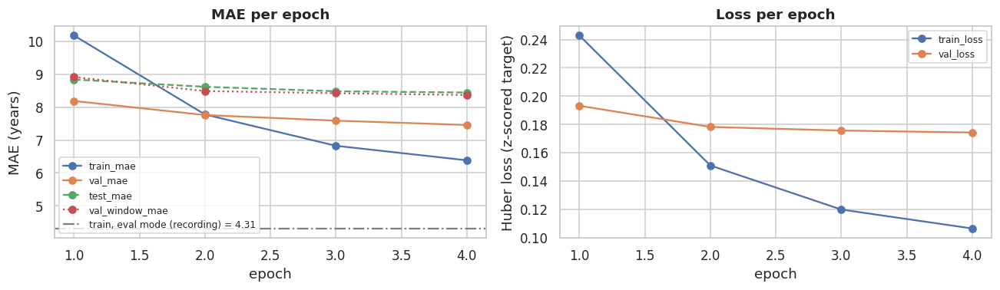

In [4]:
log = read_epoch_log(BEST_RUN)
cols = [c for c in ["train_loss", "train_mae", "val_loss", "val_mae", "val_window_mae",
                    "test_mae", "val_age_bias_slope", "val_normal_mae", "val_abnormal_mae"]
        if c in log]
display(log[cols].rename_axis("epoch"))

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ep = np.arange(1, len(log) + 1)
for c, ls in (("train_mae", "-"), ("val_mae", "-"), ("test_mae", "--"), ("val_window_mae", ":")):
    if c in log:
        ax[0].plot(ep, log[c], ls, marker="o", label=c)
train_eval_mae = regression_summary(train)["mae"]
ax[0].axhline(train_eval_mae, color="grey", ls="-.", label=f"train, eval mode (recording) = {train_eval_mae:.2f}")
ax[0].set(xlabel="epoch", ylabel="MAE (years)", title="MAE per epoch")
ax[0].legend(fontsize=8)
for c in ("train_loss", "val_loss"):
    if c in log:
        ax[1].plot(ep, log[c], marker="o", label=c)
ax[1].set(xlabel="epoch", ylabel="Huber loss (z-scored target)", title="Loss per epoch")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 2. Error summary: mean vs. median, window vs. recording, cohort

* **window**: each 10 s window scored on its own.
* **recording**: mean of the recording's window predictions (the reported metric).

`median_ae` is less sensitive to the large-error tail than the MAE. `mean_err` / `median_err` are the
signed bias. `bias_slope` is the slope of the error against age; −0.4 means a 10-year age difference
shows up as only a 6-year difference in prediction.

In [5]:
summary = summary_table({"window": win, "recording": rec})
display(summary.style.format(precision=2).background_gradient(subset=["mae", "median_ae"], cmap="Reds"))

## 3. Error and loss distributions

All ages are in years, on the original scale. Top row:

* the distribution of **true vs. predicted age** per recording; the predicted distribution is
  visibly narrower, which is regression to the mean;
* the **predicted age for each true-age decade** (box = IQR), against the diagonal where the
  prediction equals the true age;
* the ECDF of the absolute error.

The bottom row shows the per-window **training loss** (Huber δ=1 on the z-scored target) and how much
of the total loss sits in the worst windows.

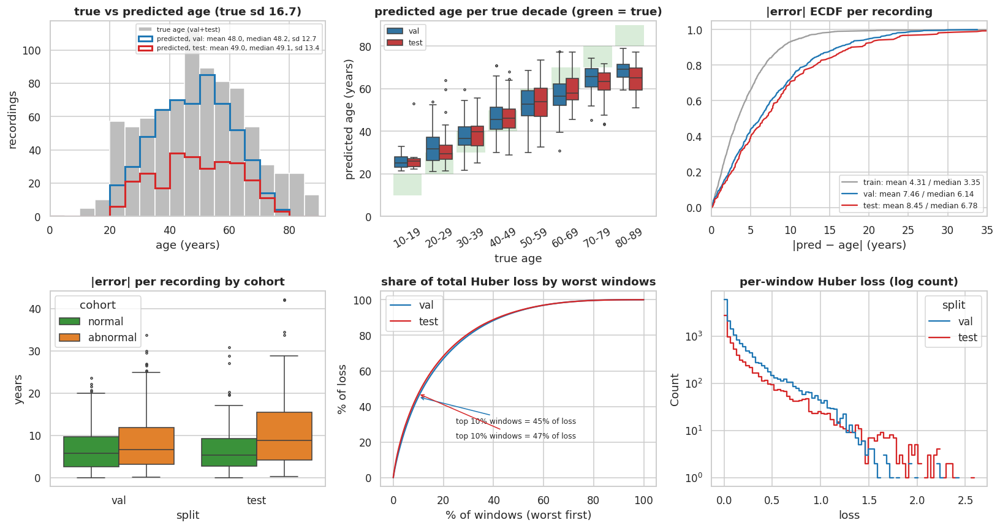

,|err| mean,|err| min,|err| 50%,|err| 75%,|err| 90%,|err| 95%,|err| max
split,,,,,,,
test,8.45,3.68e-02,6.78,11.39,17.72,23.37,42.07
val,7.46,1.45e-03,6.14,10.51,16.08,20.21,33.77


In [6]:
sigma = run.target_stats[1]
win["huber"] = np.where((win.err / sigma).abs() <= 1, 0.5 * (win.err / sigma) ** 2,
                        (win.err / sigma).abs() - 0.5)
fig, ax = plt.subplots(2, 3, figsize=(15, 8))
ev_rec = rec[rec.split != "train"]
age_bins = np.arange(0, 95, 5)
ax[0, 0].hist(ev_rec.age, bins=age_bins, color="#bdbdbd", label="true age (val+test)")
for split in ("val", "test"):
    d = ev_rec[ev_rec.split == split]
    ax[0, 0].hist(d.pred, bins=age_bins, histtype="step", lw=2, color=SPLIT_COLORS[split],
                  label=f"predicted, {split}: mean {d.pred.mean():.1f}, median {d.pred.median():.1f}, "
                        f"sd {d.pred.std():.1f}")
ax[0, 0].set(title=f"true vs predicted age (true sd {ev_rec.age.std():.1f})",
             xlabel="age (years)", ylabel="recordings", xlim=AGE_LIM)
ax[0, 0].legend(fontsize=7)
bx = ev_rec.assign(age_bin=assign_age_bin(ev_rec.age))
order = [l for l in age_bin_labels() if (bx.age_bin.astype(str) == l).sum() >= 3]
sns.boxplot(data=bx[bx.age_bin.astype(str).isin(order)], x="age_bin", y="pred", hue="split",
            order=order, palette=SPLIT_COLORS, ax=ax[0, 1], fliersize=2)
for k, lab in enumerate(order):
    lo, hi = (int(v) for v in lab.split("-"))
    ax[0, 1].fill_between([k - 0.45, k + 0.45], lo, hi + 1, color="green", alpha=0.15, lw=0)
ax[0, 1].set(title="predicted age per true decade (green = true)", xlabel="true age",
             ylabel="predicted age (years)", ylim=AGE_LIM)
ax[0, 1].tick_params(axis="x", rotation=30)
ax[0, 1].legend(fontsize=8, loc="upper left")
for split in ("train", "val", "test"):
    d = rec[rec.split == split].abs_err.sort_values()
    ax[0, 2].plot(d, np.linspace(0, 1, len(d)), color=SPLIT_COLORS[split],
                  label=f"{split}: mean {d.mean():.2f} / median {d.median():.2f}")
ax[0, 2].set(title="|error| ECDF per recording", xlabel="|pred − age| (years)", xlim=(0, 35))
ax[0, 2].legend(fontsize=8)

ev = win[win.split != "train"]
sns.boxplot(data=ev_rec, x="split", y="abs_err", hue="cohort",
            palette=COHORT_COLORS, ax=ax[1, 0], showfliers=True, fliersize=2)
ax[1, 0].set(title="|error| per recording by cohort", ylabel="years")
for split in ("val", "test"):
    h = ev[ev.split == split].huber.sort_values(ascending=False).to_numpy()
    share = np.cumsum(h) / h.sum()
    ax[1, 1].plot(np.linspace(0, 100, len(h)), share * 100, color=SPLIT_COLORS[split], label=split)
    top10 = share[int(0.1 * len(h))] * 100
    ax[1, 1].annotate(f"top 10% windows = {top10:.0f}% of loss", (10, top10),
                      xytext=(25, top10 - 15 - 10 * (split == "test")), fontsize=8,
                      arrowprops=dict(arrowstyle="->", color=SPLIT_COLORS[split]))
ax[1, 1].set(title="share of total Huber loss by worst windows", xlabel="% of windows (worst first)",
             ylabel="% of loss")
ax[1, 1].legend()
sns.histplot(data=ev, x="huber", hue="split", bins=80, log_scale=(False, True), element="step",
             fill=False, palette=SPLIT_COLORS, ax=ax[1, 2])
ax[1, 2].set(title="per-window Huber loss (log count)", xlabel="loss")
plt.tight_layout(); plt.show()

q = (rec[rec.split != "train"].groupby("split").abs_err
     .describe(percentiles=[.5, .75, .9, .95]).drop(columns=["count", "std"]))
display(q.rename(columns=lambda c: f"|err| {c}"))

## 4. Per-sample view: windows inside a recording

How much do a recording's 30 window predictions disagree? Does the disagreement flag a bad
recording? Does median pooling beat mean pooling? Does the position in the recording matter?
TUAB sessions often contain hyperventilation and photic stimulation, and patients get drowsy as a
session goes on.

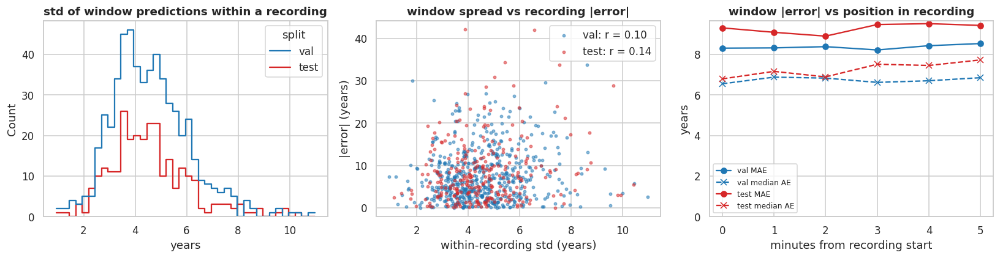

,window MAE,recording MAE (mean pool),recording MAE (median pool),mean within-rec std
split,,,,
train,5.49,4.31,4.24,4.36
val,8.37,7.46,7.53,4.58
test,9.28,8.45,8.43,4.58


In [7]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ev_rec = rec[rec.split != "train"]
sns.histplot(data=ev_rec, x="pred_std", hue="split", bins=40, element="step", fill=False,
             palette=SPLIT_COLORS, ax=ax[0])
ax[0].set(title="std of window predictions within a recording", xlabel="years")
for split in ("val", "test"):
    d = ev_rec[ev_rec.split == split]
    r = np.corrcoef(d.pred_std, d.abs_err)[0, 1]
    ax[1].scatter(d.pred_std, d.abs_err, s=8, alpha=0.5, color=SPLIT_COLORS[split],
                  label=f"{split}: r = {r:.2f}")
ax[1].set(title="window spread vs recording |error|", xlabel="within-recording std (years)",
          ylabel="|error| (years)")
ax[1].legend()
ev = win[win.split != "train"].copy()
ev["t_min"] = ev.window * 10 / 60
ev["t_bin"] = pd.cut(ev.t_min, bins=np.arange(0, ev.t_min.max() + 2, 1.0))
pos = ev.groupby(["split", "t_bin"], observed=True).agg(mae=("abs_err", "mean"),
                                                        median_ae=("abs_err", "median"),
                                                        n=("err", "size")).reset_index()
pos["t"] = pos.t_bin.apply(lambda iv: iv.left)
for split in ("val", "test"):
    d = pos[(pos.split == split) & (pos.n >= 100)]
    ax[2].plot(d.t, d.mae, marker="o", color=SPLIT_COLORS[split], label=f"{split} MAE")
    ax[2].plot(d.t, d.median_ae, marker="x", ls="--", color=SPLIT_COLORS[split],
               label=f"{split} median AE")
ax[2].set(title="window |error| vs position in recording", xlabel="minutes from recording start",
          ylabel="years", ylim=(0, None))
ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

pool = pd.DataFrame({
    "window MAE": win.groupby("split").abs_err.mean(),
    "recording MAE (mean pool)": rec.groupby("split").abs_err.mean(),
    "recording MAE (median pool)": rec.groupby("split").abs_err_median_pool.mean(),
    "mean within-rec std": rec.groupby("split").pred_std.mean(),
}).loc[["train", "val", "test"]]
display(pool)

## 5. Regression to the mean, against the train sampling density

The core failure. Young subjects are predicted older and old subjects younger than they are. The top
panel shows how many **train windows** each age contributes: the model sees ages 40–60 far more often
than children or people over 80. The middle row plots predicted against true age per recording. The
bottom-left panel shows the median predicted age (with IQR) of each true-age decade; the further it sits from the
diagonal, the stronger the pull toward the mean (~49 y). If the bias simply followed sampling
density, the worst-served bins would be the rarest ones (bottom right).

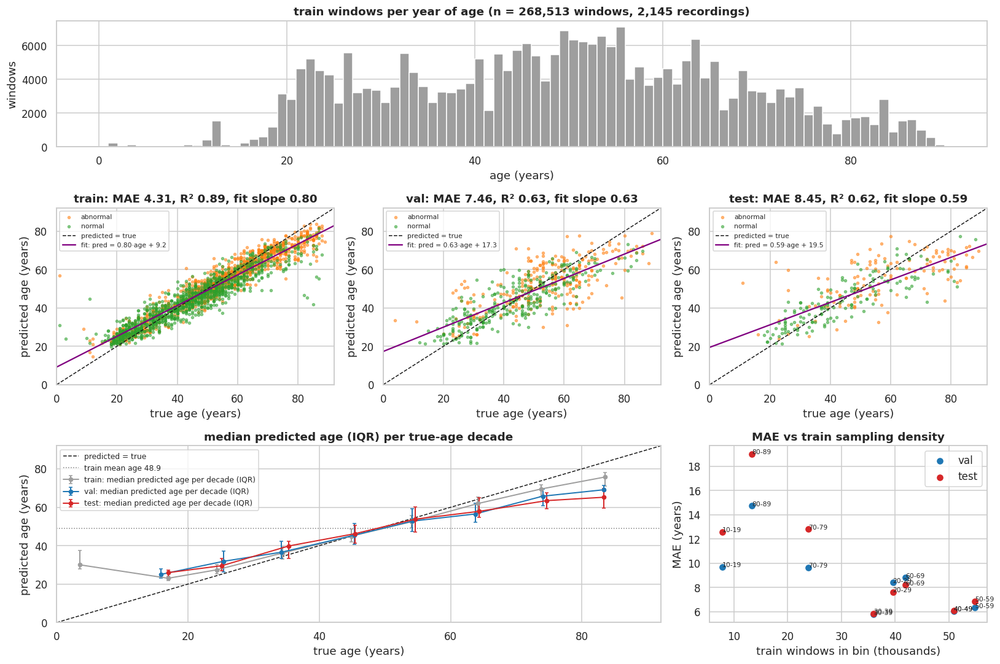

n  age_mean  pred_mean  pred_median  pred_q25  pred_q75    mae  median_ae
split age_bin                                                                             
test  10-19      6     17.00      29.58        25.98     23.31     27.30  12.58       8.23
      20-29     34     25.18      32.42        29.58     26.84     33.42   7.62       4.74
      30-39     49     35.37      39.01        39.86     33.33     42.36   5.85       4.84
      40-49     52     45.48      47.07        46.28     41.41     50.49   6.07       4.90
      50-59     51     54.65      53.73        53.84     47.01     60.32   6.87       6.18
      60-69     32     64.31      59.47        57.87     54.75     64.99   8.19       8.83
      70-79     30     74.67      61.85        63.48     59.28     67.55  12.82      10.60
      80-89     20     83.30      64.26        65.22     59.45     69.84  19.04      19.38
val   0-9        1      4.00      33.57        33.57     33.57     33.57  29.57      29.57
      10-19      9     15.89      25.58        25.05     22.99     28.01   9.69       7.36
      20-29     77     25.43      33.04        31.87     26.18     37.22   8.40       6.53
      30-39     75     34.25      38.10        36.62     33.51     42.27   5.77       3.76
      40-49    130     45.35      46.80        45.50     40.83     51.48   6.05       4.90
      50-59    119     54.19      52.94        52.80     47.38     59.08   6.33       6.15
      60-69     99     63.75      56.52        56.52     52.19     62.24   8.80       7.20
      70-79     27     74.04      64.40        65.78     60.94     69.35   9.64       8.11
      80-89     19     83.32      68.57        69.12     65.44     71.46  14.75      14.88

In [8]:
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(3, 3, height_ratios=[1, 1.4, 1.4])
ax0 = fig.add_subplot(gs[0, :])
train_ages = np.asarray([a for a in run.split("train").ages()])
ax0.hist(train_ages, bins=np.arange(0, 91, 1), color="#9e9e9e")
ax0.set(title=f"train windows per year of age (n = {len(train_ages):,} windows, "
              f"{len(train):,} recordings)", xlabel="age (years)", ylabel="windows")
for k, split in enumerate(("train", "val", "test")):
    d = rec[rec.split == split]
    a = fig.add_subplot(gs[1, k])
    for cohort, c in d.groupby("cohort"):
        a.scatter(c.age, c.pred, s=7, alpha=0.5, color=COHORT_COLORS[cohort], label=cohort)
    identity(a)
    slope, icpt = np.polyfit(d.age, d.pred, 1)
    a.plot(AGE_LIM, np.polyval([slope, icpt], AGE_LIM), color="purple", lw=1.5,
           label=f"fit: pred = {slope:.2f}·age + {icpt:.1f}")
    s = regression_summary(d)
    a.set(title=f"{split}: MAE {s['mae']:.2f}, R² {s['r2']:.2f}, fit slope {slope:.2f}")
    a.legend(fontsize=7, loc="upper left")
bins = error_by_age_bin(rec, by=["split"]).reset_index()
labels = age_bin_labels()
a = fig.add_subplot(gs[2, 0:2])
identity(a)
a.axhline(run.target_stats[0], color="grey", ls=":", lw=1, label=f"train mean age {run.target_stats[0]:.1f}")
for split in ("train", "val", "test"):
    plot_pred_by_bin(a, rec[rec.split == split], f"{split}: median predicted age per decade (IQR)",
                     SPLIT_COLORS[split], min_n=3)
a.set(title="median predicted age (IQR) per true-age decade")
a.legend(fontsize=8, loc="upper left")
a = fig.add_subplot(gs[2, 2])
dens = pd.Series(assign_age_bin(pd.Series(train_ages))).value_counts().reindex(labels)
for split in ("val", "test"):
    d = bins[bins.split == split].set_index("age_bin").reindex(labels)
    ok = d.n >= 5
    a.scatter(dens[ok] / 1000, d.mae[ok], color=SPLIT_COLORS[split], label=split)
    for lab in np.array(labels)[ok.to_numpy()]:
        a.annotate(lab, (dens[lab] / 1000, d.mae[lab]), fontsize=7)
a.set(xlabel="train windows in bin (thousands)", ylabel="MAE (years)",
      title="MAE vs train sampling density")
a.legend()
plt.tight_layout(); plt.show()
display(error_by_age_bin(rec[rec.split != "train"], by=["split"])
        [["n", "age_mean", "pred_mean", "pred_median", "pred_q25", "pred_q75", "mae", "median_ae"]])

## 6. Post-hoc bias correction (fit on val, apply to test)

Each correction is fitted on the validation recordings (all, or normal only, which is the usual
"healthy controls" choice) and applied to test.

* **cole**: invert `pred = slope·age + intercept`. Deployable, since it uses only the prediction.
* **recalibrate**: least squares of age on prediction. Deployable and MSE-optimal.
* **age_level**: subtract the age-dependent bias using the **true age**. This is the standard
  brain-age-*gap* correction. It is not an age estimate, and its MAE cannot be compared with the others.

fit on val: pred = 0.634 * age + 17.29   |   age ~= 0.999 * pred + 0.46


deployable  test MAE  median AE  bias slope  normal MAE  abnormal MAE
fit on       method                                                                            
val (all)    none               True      8.45       6.78       -0.41        6.60         10.65
             cole               True      9.94       8.45       -0.08        8.40         11.78
             recalibrate        True      8.44       6.61       -0.41        6.64         10.59
             age_level         False      6.30       5.36       -0.05        5.33          7.47
val (normal) none               True      8.45       6.78       -0.41        6.60         10.65
             cole               True      9.55       6.89       -0.11        7.73         11.72
             recalibrate        True      8.34       6.77       -0.37        6.51         10.53
             age_level         False      6.30       4.55       -0.07        5.10          7.73

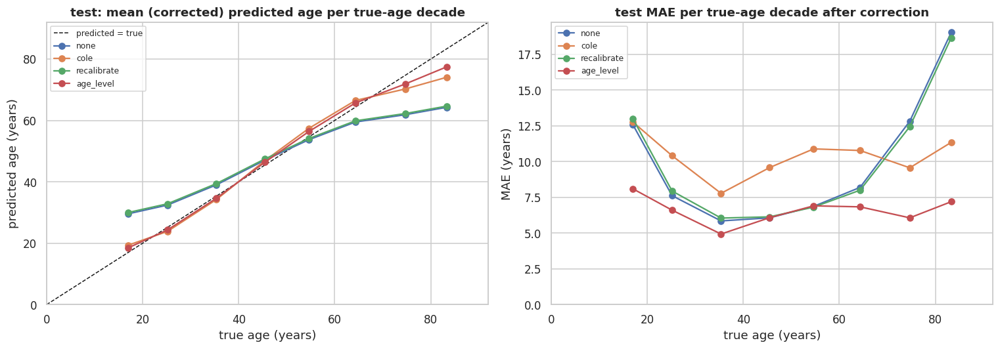

In [9]:
rows, curves = [], {}
for fit_name, fit in (("val (all)", val), ("val (normal)", val[val.cohort == "normal"])):
    params = fit_bias_correction(fit.pred, fit.age)
    for method in CORRECTIONS:
        p = apply_bias_correction(test.pred, params, method, test.age)
        d = test.assign(pred=p)
        s = regression_summary(d)
        rows.append({"fit on": fit_name, "method": method, "deployable": method != "age_level",
                     "test MAE": s["mae"], "median AE": s["median_ae"], "bias slope": s["bias_slope"],
                     "normal MAE": regression_summary(d[d.cohort == "normal"])["mae"],
                     "abnormal MAE": regression_summary(d[d.cohort == "abnormal"])["mae"]})
        if fit_name == "val (all)":
            curves[method] = error_by_age_bin(add_errors(d.copy()))
    if fit_name == "val (all)":
        print("fit on val: pred = %.3f * age + %.2f   |   age ~= %.3f * pred + %.2f"
              % (params["slope"], params["intercept"], params["recal_a"], params["recal_b"]))
display(pd.DataFrame(rows).set_index(["fit on", "method"]))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
identity(ax[0])
for method, c in curves.items():
    c = c[c.n >= 3]
    ax[0].plot(c.age_mean, c.pred_mean, marker="o", label=method)
    ax[1].plot(c.age_mean, c.mae, marker="o", label=method)
ax[0].set(title="test: mean (corrected) predicted age per true-age decade")
ax[1].set(title="test MAE per true-age decade after correction", xlabel="true age (years)",
          ylabel="MAE (years)", xlim=AGE_LIM, ylim=(0, None))
for a in ax: a.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 7. Normal vs. abnormal, and the spectral correlates of the error

The abnormal recordings are older and their EEG is slower: more delta/theta, less alpha and a lower
peak alpha frequency (PAF). EEG slowing is also a classic marker of ageing. The question is whether
the model mistakes pathological slowing for age.

Features per recording, after CAR, over up to 6 of its scored windows: channel-averaged relative
band power (1–45 Hz), posterior PAF (O1/O2/P3/P4/Pz/T5/T6, 7–13 Hz, 0.5 Hz resolution) and the
theta/alpha ratio. A PAF of 7 Hz sits at the edge of the search band and means *no alpha peak*, which
is typical of diffusely slowed abnormal EEG. The error is **age-detrended** (its linear trend in age is removed) so that regression to the mean does
not masquerade as a spectral effect.

cohort,abnormal,normal
median per recording,,
age,55.00,44.00
abs_err,7.42,5.44
err,-0.77,0.06
paf,7.50,10.00
theta_alpha,1.40,0.47
rel_delta,0.53,0.37
rel_theta,0.16,0.11
rel_alpha,0.11,0.24
rel_beta,0.10,0.16


,"ρ(feature, age)","ρ(feature, age-detrended error)",ρ within normal,ρ within abnormal
paf,-0.27,-0.22,-0.13,-0.15
theta_alpha,0.17,0.17,-0.02,0.15
rel_delta,0.06,0.09,-0.17,0.15
rel_theta,0.05,0.06,-0.08,0.05
rel_alpha,-0.15,-0.16,-0.00,-0.13
rel_beta,-0.04,-0.07,0.23,-0.17
amp_uv,-0.05,-0.05,-0.15,-0.02


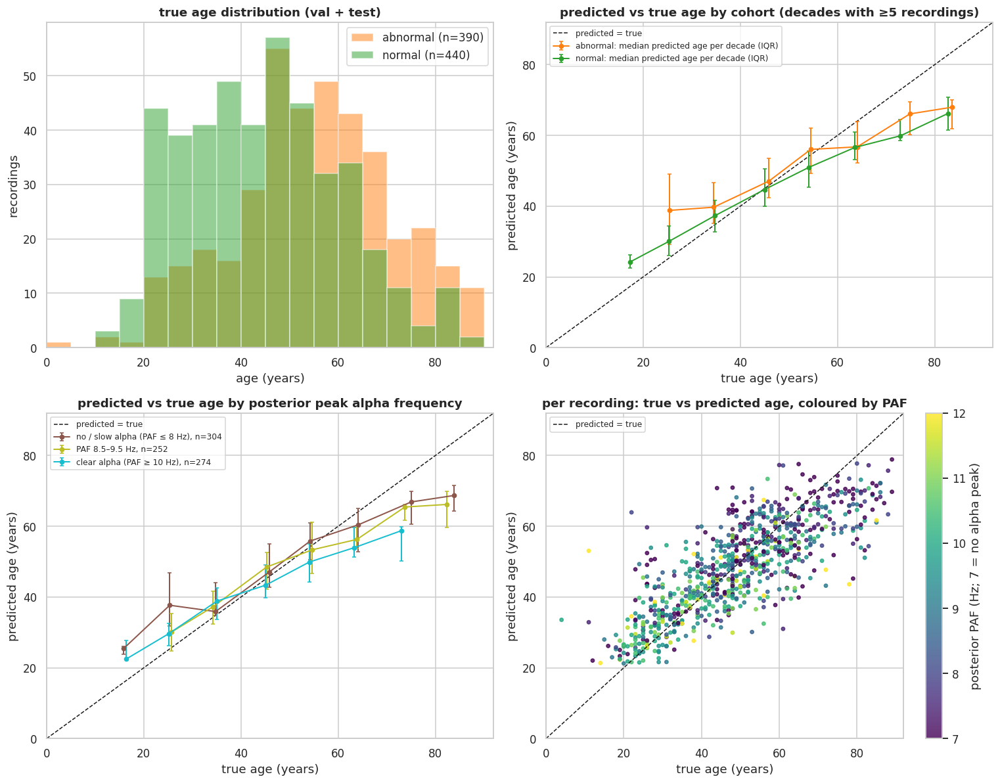

,n,abnormal_share,true_age,predicted_age,age_detrended_error,mae
paf_group,,,,,,
≤ 8 Hz,304,0.80,54.51,53.69,1.66,8.77
8.5–9.5 Hz,252,0.38,48.23,47.52,-0.35,7.60
≥ 10 Hz,274,0.19,43.77,43.11,-2.46,6.85


In [10]:
fpath = os.path.join(BEST_RUN, "analysis", "spectral_features.parquet")
if os.path.exists(fpath):
    feats = pd.read_parquet(fpath)
else:
    feats = pd.concat([recording_spectral_features(run.split(s), win[win.split == s], run.ch_names)
                       for s in ("val", "test")], ignore_index=True)
    feats.to_parquet(fpath)
ev_rec = rec[rec.split != "train"].merge(feats, on=["split", "recording"])
ev_rec["err_detrended"] = ev_rec.err - np.polyval(np.polyfit(ev_rec.age, ev_rec.err, 1), ev_rec.age)
FEATS = ["paf", "theta_alpha", "rel_delta", "rel_theta", "rel_alpha", "rel_beta", "amp_uv"]

display(ev_rec.groupby("cohort")[["age", "abs_err", "err"] + FEATS].median()
        .T.rename_axis("median per recording"))
corr = pd.DataFrame({
    "ρ(feature, age)": ev_rec[FEATS].corrwith(ev_rec.age, method="spearman"),
    "ρ(feature, age-detrended error)": ev_rec[FEATS].corrwith(ev_rec.err_detrended, method="spearman"),
    "ρ within normal": ev_rec[ev_rec.cohort == "normal"][FEATS].corrwith(
        ev_rec[ev_rec.cohort == "normal"].err_detrended, method="spearman"),
    "ρ within abnormal": ev_rec[ev_rec.cohort == "abnormal"][FEATS].corrwith(
        ev_rec[ev_rec.cohort == "abnormal"].err_detrended, method="spearman"),
})
display(corr.style.format(precision=2).background_gradient(cmap="RdBu_r", vmin=-0.4, vmax=0.4))

fig, ax = plt.subplots(2, 2, figsize=(14, 11))
for cohort, d in ev_rec.groupby("cohort"):
    ax[0, 0].hist(d.age, bins=np.arange(0, 95, 5), alpha=0.5, color=COHORT_COLORS[cohort],
                  label=f"{cohort} (n={len(d)})")
ax[0, 0].set(title="true age distribution (val + test)", xlabel="age (years)", ylabel="recordings",
             xlim=AGE_LIM)
ax[0, 0].legend()
identity(ax[0, 1])
for cohort, d in ev_rec.groupby("cohort"):
    plot_pred_by_bin(ax[0, 1], d, f"{cohort}: median predicted age per decade (IQR)", COHORT_COLORS[cohort])
ax[0, 1].set(title="predicted vs true age by cohort (decades with ≥5 recordings)")
ax[0, 1].legend(fontsize=8, loc="upper left")
paf_groups = {"no / slow alpha (PAF ≤ 8 Hz)": (ev_rec.paf <= 8.0, "#8c564b"),
              "PAF 8.5–9.5 Hz": ((ev_rec.paf > 8.0) & (ev_rec.paf < 10.0), "#bcbd22"),
              "clear alpha (PAF ≥ 10 Hz)": (ev_rec.paf >= 10.0, "#17becf")}
identity(ax[1, 0])
for name, (mask, color) in paf_groups.items():
    plot_pred_by_bin(ax[1, 0], ev_rec[mask], f"{name}, n={int(mask.sum())}", color)
ax[1, 0].set(title="predicted vs true age by posterior peak alpha frequency")
ax[1, 0].legend(fontsize=8, loc="upper left")
sc = ax[1, 1].scatter(ev_rec.age, ev_rec.pred, c=ev_rec.paf.clip(7, 12), cmap="viridis", s=12, alpha=0.8)
identity(ax[1, 1])
plt.colorbar(sc, ax=ax[1, 1], label="posterior PAF (Hz; 7 = no alpha peak)")
ax[1, 1].set(title="per recording: true vs predicted age, coloured by PAF")
ax[1, 1].legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()
display(ev_rec.assign(paf_group=pd.cut(ev_rec.paf, [0, 8.0, 9.75, 99],
                                       labels=["≤ 8 Hz", "8.5–9.5 Hz", "≥ 10 Hz"]))
        .groupby("paf_group", observed=True)
        .agg(n=("age", "size"), abnormal_share=("cohort", lambda c: (c == "abnormal").mean()),
             true_age=("age", "mean"), predicted_age=("pred", "mean"),
             age_detrended_error=("err_detrended", "median"), mae=("abs_err", "mean")))

### Average spectra of over- vs. under-predicted recordings, age-matched

Recordings in the top and bottom quintiles of the age-detrended error. Each quintile is compared
within the 40–70 age range, so that the groups have similar ages.

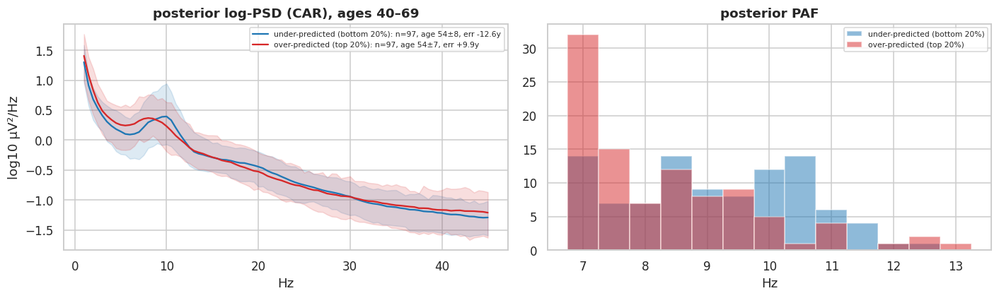

under-predicted (bottom 20%)     abnormal share 43%, median PAF 9.0 Hz, median theta/alpha 0.73
over-predicted (top 20%)         abnormal share 72%, median PAF 8.0 Hz, median theta/alpha 1.25


In [11]:
mid = ev_rec[(ev_rec.age >= 40) & (ev_rec.age < 70)]
lo, hi = mid.err_detrended.quantile([0.2, 0.8])
groups = {"under-predicted (bottom 20%)": mid[mid.err_detrended <= lo],
          "over-predicted (top 20%)": mid[mid.err_detrended >= hi]}
post = [i for i, c in enumerate(run.ch_names) if c.upper() in POSTERIOR]
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for (name, g), color in zip(groups.items(), ("#1f77b4", "#d62728")):
    psds = []
    for _, r in g.iterrows():
        idx = win[(win.split == r.split) & (win.recording == r.recording)].idx.to_numpy()[:6]
        ds = run.split(r.split)
        x = np.stack([common_average_reference(load_window(ds, i)) for i in idx])
        _, freqs, psd = band_powers(x)
        psds.append(psd.mean(0)[post].mean(0))
    psds = np.log10(np.stack(psds))
    keep = (freqs >= 1) & (freqs <= 45)
    ax[0].plot(freqs[keep], psds.mean(0)[keep], color=color,
               label=f"{name}: n={len(g)}, age {g.age.mean():.0f}±{g.age.std():.0f}, "
                     f"err {g.err.mean():+.1f}y")
    ax[0].fill_between(freqs[keep], *np.percentile(psds, [25, 75], axis=0)[:, keep], color=color, alpha=0.15)
    ax[1].hist(g.paf, bins=np.arange(6.75, 13.5, 0.5), alpha=0.5, color=color, label=name)
ax[0].set(title="posterior log-PSD (CAR), ages 40–69", xlabel="Hz", ylabel="log10 µV²/Hz")
ax[0].legend(fontsize=7)
ax[1].set(title="posterior PAF", xlabel="Hz")
ax[1].legend(fontsize=7)
plt.tight_layout(); plt.show()
for name, g in groups.items():
    print(f"{name:32s} abnormal share {np.mean(g.cohort == 'abnormal'):.0%}, median PAF {g.paf.median():.1f} Hz, "
          f"median theta/alpha {g.theta_alpha.median():.2f}")

## 8. Real EEG: accurate vs. too young vs. too old, at the same true age

For each age in `COMPARE_AGES` (Parameters), three val/test recordings of about that true age
(±3 y): the one predicted **most accurately**, the one predicted **youngest** (under-predicted)
and the one predicted **oldest** (over-predicted). The EEG is real: one 10 s window per recording
(the window whose prediction is closest to the recording's mean), common-average referenced as the
model sees it, 19 standard 10-20 channels, and the **same µV scale** in all three panels. Below each
figure are the per-window predictions across the recording, the posterior spectra and the relative
band powers.

Change `COMPARE_AGES`, or call `ex.compare_at_age(age, tol=3, cohort="normal", split="test")`
yourself.

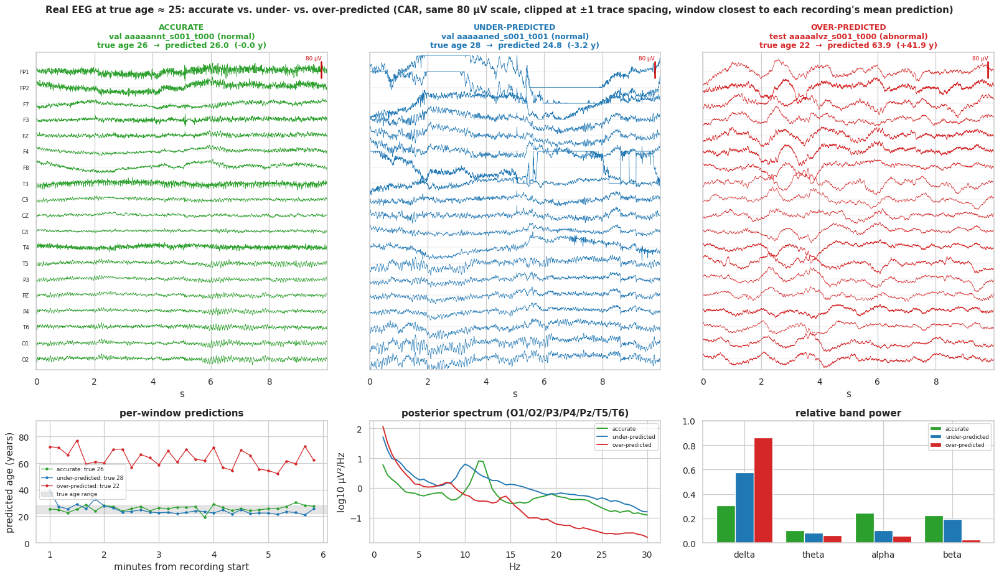

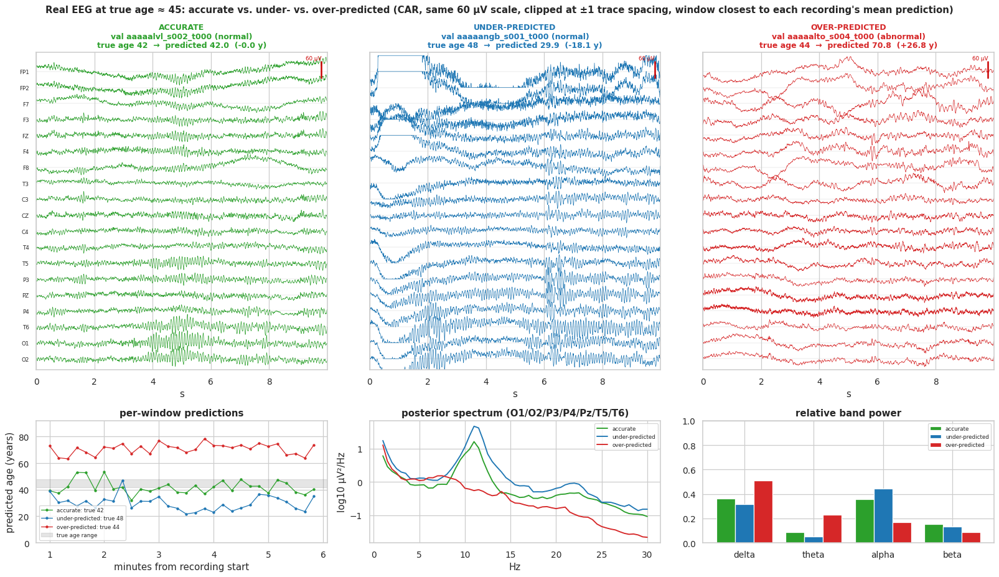

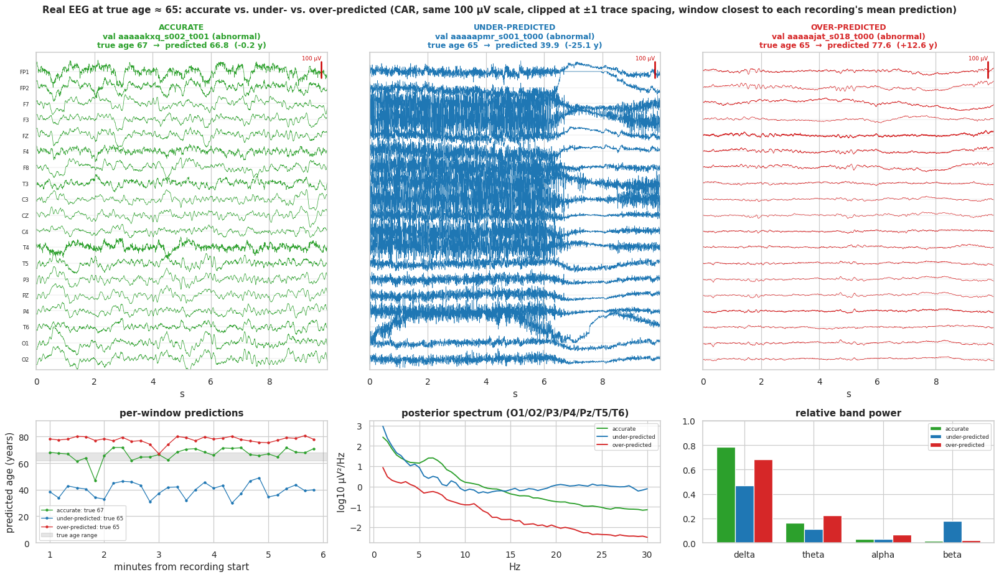

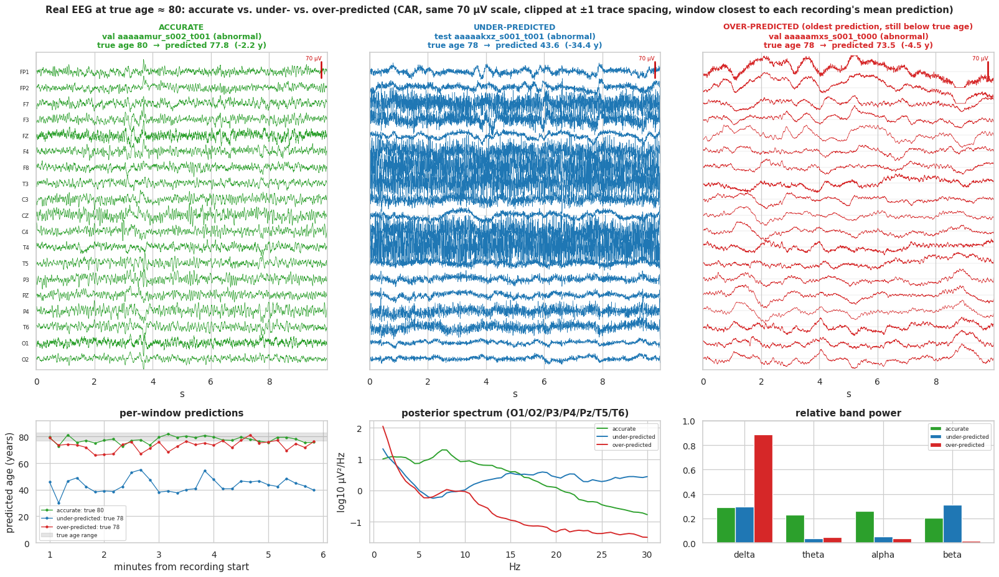

In [12]:
ex = AgeExplorer(run, win, rec, feats)
for age in COMPARE_AGES:
    fig = ex.compare_at_age(age)
    plt.show()

**What these comparisons show (M1, as executed).** At the same true age the three outcomes look
different on the screen:

* **Too old** (red): slow EEG. Delta/theta dominate (50–89% delta), with a low or absent posterior
  alpha peak and little beta. Examples: a 22-year-old predicted 64, and a 44-year-old predicted 71
  (both abnormal, diffuse slowing).
* **Too young** (blue): *fast* EEG, of two kinds. At 45 it is a normal recording with a strong,
  high-frequency alpha rhythm (48 → 30). At 65 and 80 it is heavy high-frequency **muscle (EMG)
  artifact** across most channels, with beta at 17–31% of the power (65 → 40, 78 → 44). The model
  reads both as a "young" spectrum. Artifact-contaminated recordings are a concrete, fixable source of
  the largest under-predictions (artifact rejection or EMG-robust inputs).
* **Accurate** (green): an age-typical background, e.g. a clear ~11 Hz alpha at 26 and 42.
* At 80, regression to the mean is visible directly: even the *oldest* prediction near 80 is below
  the true age (78 → 73.5). At 25, the *youngest* prediction is only 3 years too young (28 → 25),
  because nearly every young recording is pulled upward.

The per-window traces show that these are consistent offsets across the whole recording, not a few
bad windows.

### 8b. The extreme cases

The two most accurate, most over-predicted and most under-predicted recordings in val and test
(any age). Each figure shows its most representative window, all 30 window predictions on the age
axis, the posterior spectrum against age-matched normal recordings, and the band powers.

,split,kind,recording,cohort,age,pred,err,pred_std,n_windows
0,val,best,aaaaannt_s001_t000,normal,26.0,26.00,-1.45e-03,2.15,30
1,val,best,aaaaalvl_s002_t000,normal,42.0,41.98,-2.27e-02,5.11,30
2,val,over-predicted,aaaaancc_s001_t000,abnormal,4.0,33.57,2.96e+01,6.99,30
3,val,over-predicted,aaaaagxr_s009_t001,abnormal,27.0,53.94,2.69e+01,4.69,30
4,val,under-predicted,aaaaamtk_s001_t000,abnormal,79.0,45.23,-3.38e+01,8.62,30
5,val,under-predicted,aaaaampk_s001_t000,abnormal,61.0,31.02,-3.00e+01,1.83,30
6,test,best,aaaaapof_s001_t000,normal,37.0,37.04,3.68e-02,7.37,30
7,test,best,aaaaaoeg_s001_t000,normal,43.0,42.94,-5.96e-02,4.06,30
8,test,over-predicted,aaaaaohb_s001_t000,abnormal,11.0,53.07,4.21e+01,3.89,30
9,test,over-predicted,aaaaalvz_s001_t000,abnormal,22.0,63.95,4.19e+01,6.58,30


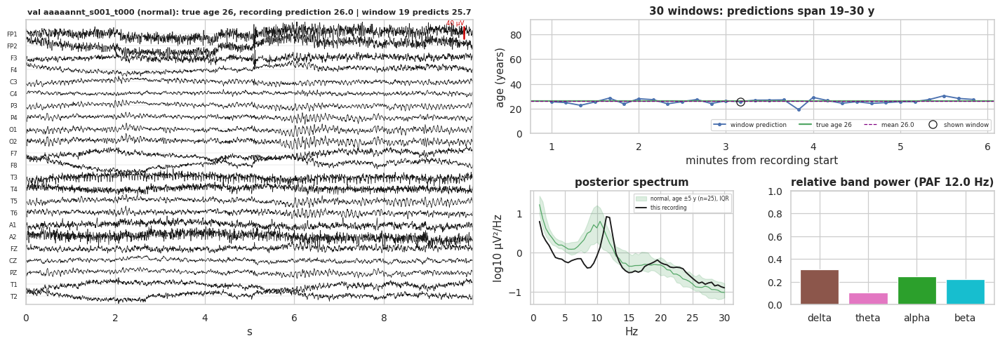

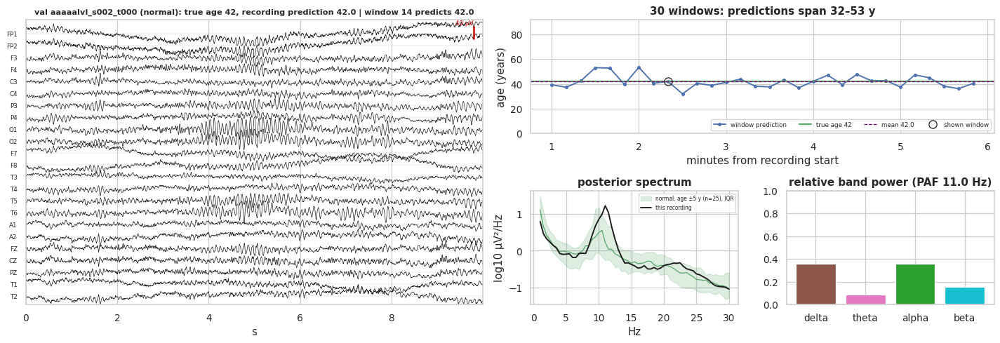

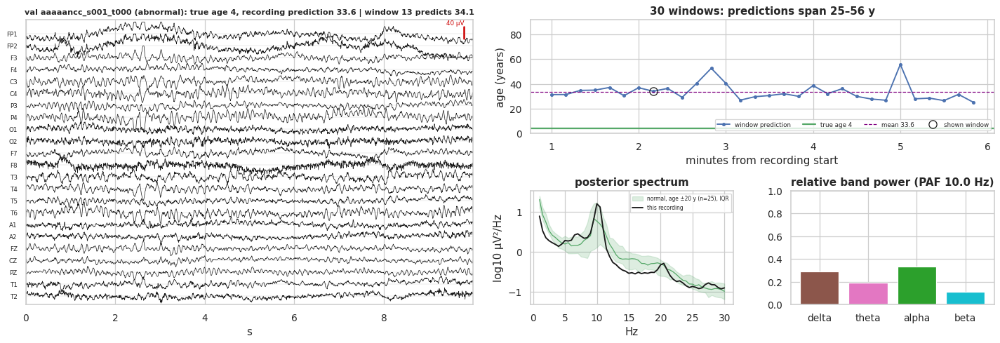

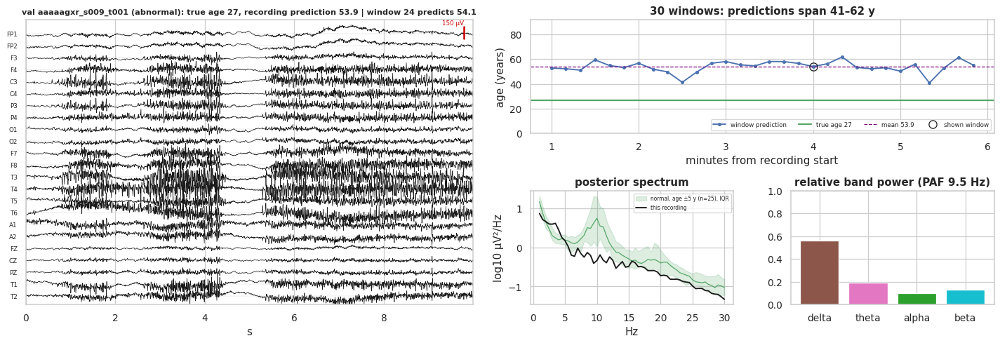

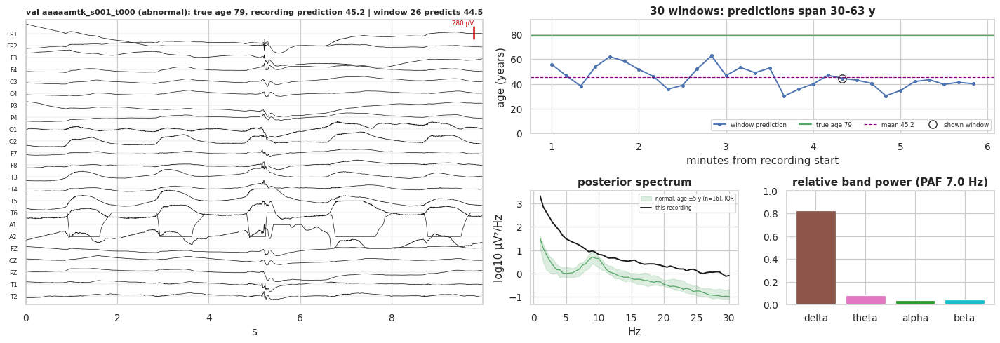

...

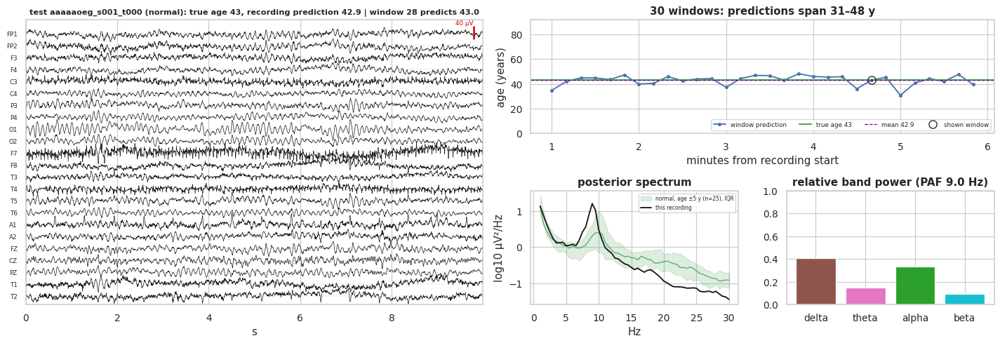

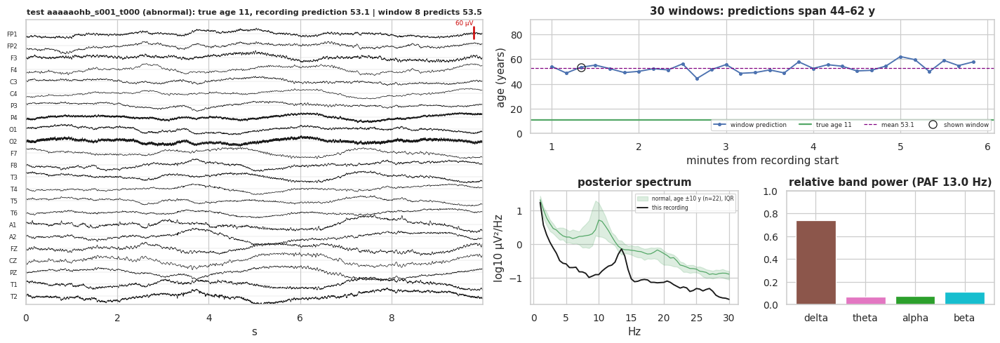

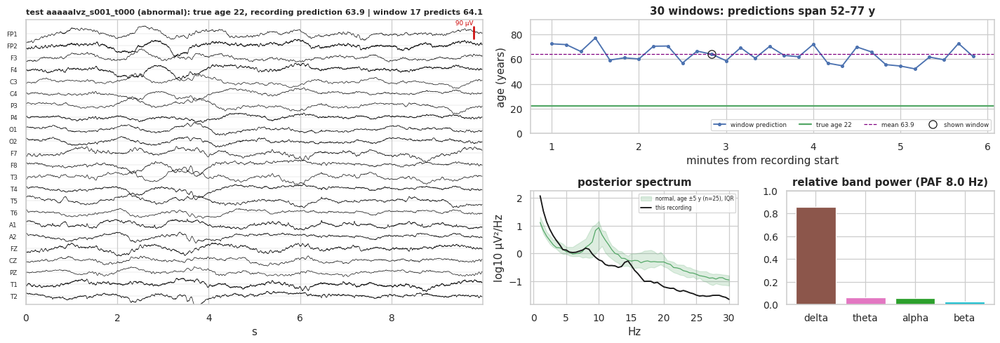

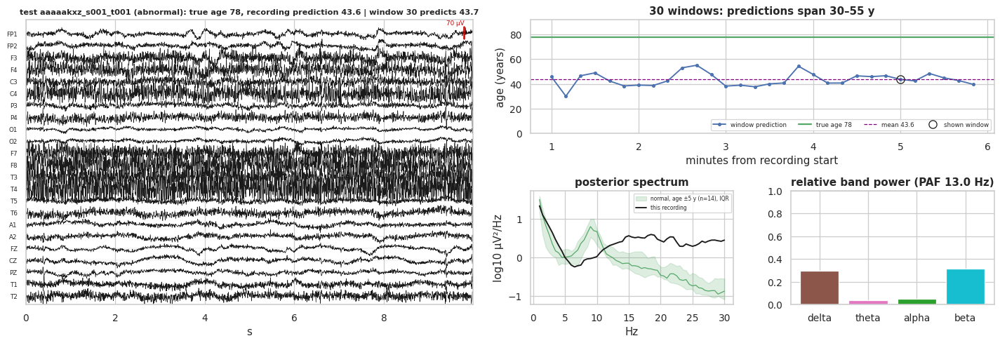

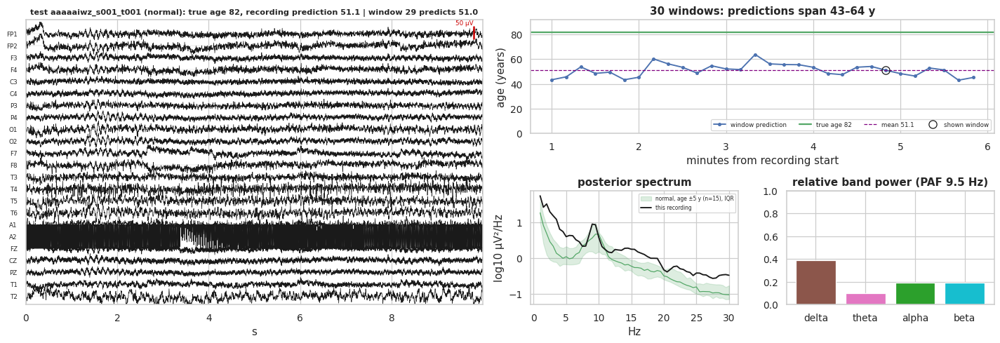

In [13]:
examples = pd.concat([pick_examples(rec[rec.split == s], n=2) for s in ("val", "test")],
                     ignore_index=True)
display(examples[["split", "kind", "recording", "cohort", "age", "pred", "err", "pred_std", "n_windows"]])
for _, r in examples.iterrows():
    fig = ex.show(r.recording, split=r.split)
    plt.show()

**What the extreme cases show (M1, as executed).** Every one of the most over-predicted recordings
is *abnormal* and young: a 4-year-old predicted 34, an 11-year-old predicted 53, and a 22-year-old
predicted 64. The 22-year-old's spectrum has about 80% delta power and no alpha peak, which is
diffuse slowing that the model reads as an old brain. The most under-predicted are old (61–82 y),
mostly abnormal, and are pulled toward the mean. The best-predicted recordings are normal adults in
the dense 25–45 range.

### 8c. Interactive explorer

Pick split, outcome (over/under/accurate), cohort and true-age range; the recording list is sorted
by that outcome and shows *true age → predicted (error)*. Untick *representative window* to step
through all 30 windows with the slider; *channels* switches between the 10-20 set, posterior only
and all 23; *common average reference* and *clip artifacts* toggle the display. Needs a live
kernel; the saved notebook does not keep widget output.

In [14]:
ex.widget()

### 8d. Playground

Edit and re-run. Useful calls:

* `ex.find(age=70, tol=3, kind="under", cohort="normal", split="test", n=10)`: candidates as a
  table (`kind`: `"accurate"`, `"under"`, `"over"`, or `None` = sorted by age).
* `ex.show(recording, window=None, channels=None, seconds=(0, 10), car=True, clip=1.0)`: one
  recording. `window` is the position 0–29 in the recording; `channels` is a list such as
  `["O1", "O2", "PZ"]`; `seconds=(2, 6)` zooms in.
* `ex.compare_at_age(age, tol=3, cohort=None, split=None, channels=STANDARD_19)`: the three-way EEG
  comparison.
* `ex.windows_of(recording)`: every window's prediction; `ex.signal(split, idx)` returns the raw
  array (µV, `[23, 2000]`).

In [15]:
ex.find(age=70, kind="under", cohort="normal", n=5)

,split,recording,cohort,age,pred,err,pred_std,n_windows,paf,rel_delta,rel_alpha
0,test,aaaaajje_s001_t000,normal,72.0,43.21,-28.79,5.76,30,9.0,0.38,0.28
1,test,aaaaajbh_s002_t000,normal,67.0,51.26,-15.74,4.92,30,9.5,0.18,0.32
2,test,aaaaaayx_s002_t000,normal,69.0,55.62,-13.38,3.99,30,9.0,0.42,0.17
3,val,aaaaaoma_s001_t000,normal,67.0,53.97,-13.03,3.81,30,10.0,0.45,0.42
4,test,aaaaalbt_s002_t000,normal,68.0,55.03,-12.97,4.97,30,8.5,0.35,0.22


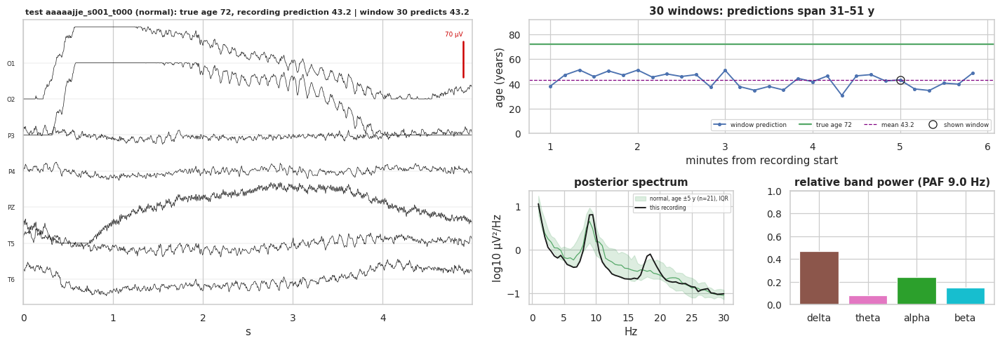

In [16]:
first = ex.find(age=70, kind="under", cohort="normal", n=1).iloc[0]
fig = ex.show(first.recording, channels=["O1", "O2", "P3", "P4", "PZ", "T5", "T6"], seconds=(0, 5))
plt.show()

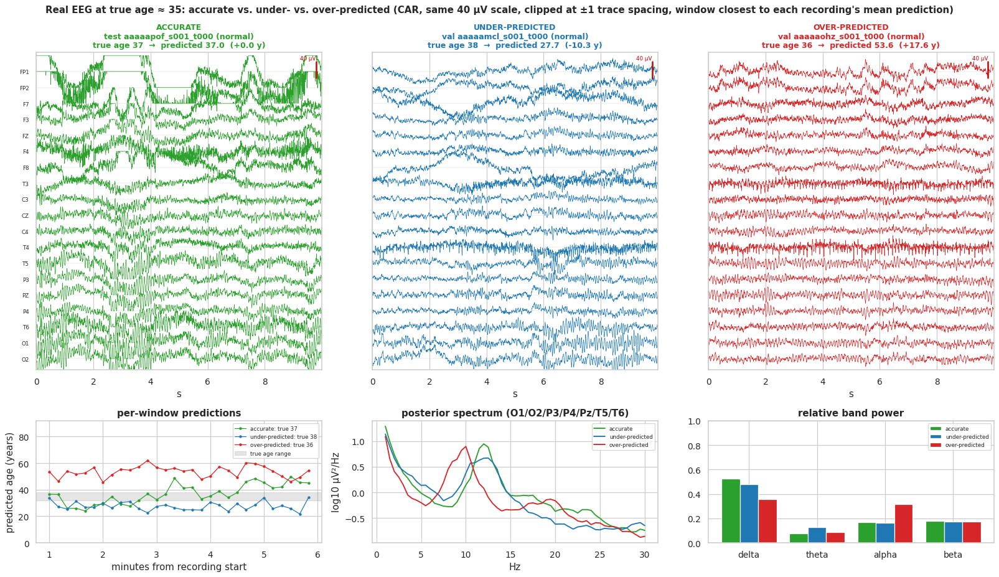

In [17]:
fig = ex.compare_at_age(35, cohort="normal")
plt.show()

## 9. Run comparison: does any variant change the age-bin bias?

The same recording-level analysis for every available local run (val/test predictions are cached
per run). The short ablations that ran on SageMaker (EMA, LoRA, soft labels, dropout, …) are listed
in the table below from their ClearML summaries; their checkpoints are not local.

,val MAE,test MAE,test normal,test abnormal
run,,,,
"E2 baseline (D, 4 ep)",7.68,8.25,–,–
M1 mixup 0.4,7.46,8.45,6.60,10.65
M1c C-Mixup σ=5,7.54,8.23,6.50,10.29
M12 mixup+EMA,7.48,8.45,6.57,10.69
M2 EMA eval,7.58,8.17,6.35,10.35
M3 LoRA r16,7.68,9.24,7.41,11.42
M4 soft labels,7.67,8.59,6.92,10.57
F1 layer decay 0.5,7.74,8.36,6.42,10.68
F2 dropout 0.1,13.25,15.17,13.37,17.32


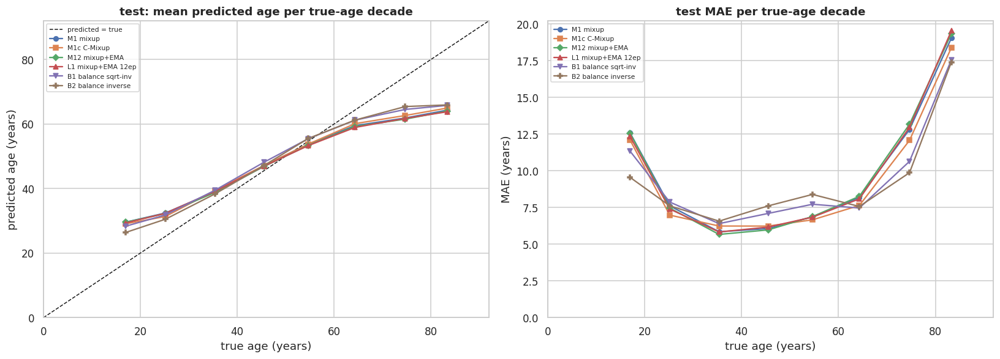

,M1 mixup,M1c C-Mixup,M12 mixup+EMA,L1 mixup+EMA 12ep,B1 balance sqrt-inv,B2 balance inverse,true (mean age)
test decade,,,,,,,
10-19,29.6,29.1,29.6,29.3,28.3,26.4,17.0
20-29,32.4,31.3,32.3,32.3,31.8,30.5,25.2
30-39,39.0,39.4,38.7,39.1,39.4,38.3,35.4
40-49,47.1,47.1,46.8,46.9,48.1,47.1,45.5
50-59,53.7,53.7,53.4,53.3,55.4,55.5,54.6
60-69,59.5,60.1,59.2,58.9,61.2,61.2,64.3
70-79,61.8,62.6,61.5,61.7,64.5,65.4,74.7
80-89,64.3,64.9,64.0,63.8,65.7,65.9,83.3


In [18]:
clearml_short = pd.DataFrame([
    ("E2 baseline (D, 4 ep)", 7.68, 8.25, None, None), ("M1 mixup 0.4", 7.46, 8.45, 6.60, 10.65),
    ("M1c C-Mixup σ=5", 7.54, 8.23, 6.50, 10.29), ("M12 mixup+EMA", 7.48, 8.45, 6.57, 10.69),
    ("M2 EMA eval", 7.58, 8.17, 6.35, 10.35), ("M3 LoRA r16", 7.68, 9.24, 7.41, 11.42),
    ("M4 soft labels", 7.67, 8.59, 6.92, 10.57), ("F1 layer decay 0.5", 7.74, 8.36, 6.42, 10.68),
    ("F2 dropout 0.1", 13.25, 15.17, 13.37, 17.32), ("F3 drop path 0.2", 7.70, 8.41, 6.31, 10.91),
    ("F4 weight decay 0.1", 7.66, 8.24, 6.49, 10.32), ("G1 head init 1.0", 7.76, 8.38, 6.64, 10.45),
    ("H1 layer decay 0.75", 7.71, 8.67, 6.64, 11.09), ("H2 layer decay 0.85", 7.86, 8.54, 6.74, 10.69),
], columns=["run", "val MAE", "test MAE", "test normal", "test abnormal"]).set_index("run")
display(clearml_short.style.format(precision=2, na_rep="–")
        .highlight_min(subset=["val MAE", "test MAE"], color="#c7e9c0"))

comp_rows, comp_bins = [], {}
for name, d in COMPARE.items():
    rd = resolve_run_dir(d)
    # checkpoint-best.pth exists from the first epoch on; only finished runs count.
    if not rd or not os.path.exists(os.path.join(rd, "checkpoint-final.pth")):
        print(f"skip {name}: no finished run yet")
        continue
    r = per_recording(cached_predictions(rd, splits=("val", "test")))
    for split in ("val", "test"):
        s = regression_summary(r[r.split == split])
        d = r[r.split == split]
        comp_rows.append({"run": name, "split": split, **{k: s[k] for k in
                          ("mae", "median_ae", "r2", "bias_slope")},
                          "pred sd": d.pred.std(), "true sd": d.age.std()})
    comp_bins[name] = error_by_age_bin(r[r.split == "test"])
comp = pd.DataFrame(comp_rows).pivot(index="run", columns="split")
display(comp.style.format(precision=2))

fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
identity(ax[0])
markers = "osD^vP*X"
for k, (name, b) in enumerate(comp_bins.items()):
    b = b[b.n >= 3]
    ax[0].plot(b.age_mean, b.pred_mean, marker=markers[k % len(markers)], ms=5, label=name)
    ax[1].plot(b.age_mean, b.mae, marker=markers[k % len(markers)], ms=5, label=name)
ax[0].set(title="test: mean predicted age per true-age decade")
ax[1].set(title="test MAE per true-age decade", xlabel="true age (years)", ylabel="MAE (years)",
          xlim=AGE_LIM, ylim=(0, None))
for a in ax: a.legend(fontsize=7, loc="upper left")
plt.tight_layout(); plt.show()
display(pd.DataFrame({name: b.pred_mean for name, b in comp_bins.items()})
        .assign(**{"true (mean age)": next(iter(comp_bins.values())).age_mean})
        .rename_axis("test decade").style.format(precision=1)
        .set_caption("mean predicted age per true-age decade (test recordings)"))

**Age-balanced loss (B1 = sqrt-inverse, B2 = inverse weights; short schedule, no mixup), as executed.**
The balanced loss moves the tails toward the diagonal, but only partly, and it costs accuracy in the
dense middle:

| test decade (true mean age) | M1 mixup | B1 sqrt-inv | B2 inverse |
|---|---|---|---|
| 10–19 (17) | predicted 29.6 | 28.3 | **26.4** |
| 20–29 (25) | 32.4 | 31.8 | 30.5 |
| 50–59 (55) | 53.7 | 55.4 | 55.5 |
| 70–79 (75) | 61.8 | 64.5 | **65.4** |
| 80–89 (83) | 64.3 | 65.7 | 65.9 |

* Prediction spread widens (test pred sd 13.4 → 14.6 / 15.6, true 18.1) and the bias slope shrinks
  (val −0.37 → −0.32 / −0.29).
* Per-decade MAE improves where the weights are large (B2, 10–19: 12.6 → 9.6; 70–79: 12.8 → 9.9)
  and worsens where they are small (40–59: ~6.0–6.9 → 7.6–8.4). Overall MAE goes up: val 7.83 / 7.96 and
  test 8.47 / 8.57, against 7.68 / 8.25 for the matching no-mixup baseline E2.
* The 80–89 decade barely moves (+1.5 y). Reweighting cannot create information that the EEG of the
  oldest recordings does not carry (section 7: slowing and pathology dominate there).

**Use it when** the downstream use needs less age-dependent bias (e.g. brain-age gap across the
age range) more than the lowest MAE. **Not** as a way to lower MAE.

## 10. Takeaways

The narrative is written against the executed outputs above. Rerun the notebook after new runs
finish; section 9 picks them up automatically.

In [19]:
s_val, s_test, s_train = (regression_summary(d) for d in (val, test, train))
params = fit_bias_correction(val.pred, val.age)
cole = regression_summary(test.assign(pred=apply_bias_correction(test.pred, params, "cole")))
by_bin = error_by_age_bin(test)
print(f"* Memorization: recording MAE train {s_train['mae']:.2f} (eval mode) vs val {s_val['mae']:.2f} "
      f"/ test {s_test['mae']:.2f}.")
print(f"* Mean vs median: test MAE {s_test['mae']:.2f}, median AE {s_test['median_ae']:.2f}, "
      f"P90 {s_test['p90_ae']:.2f}; the tail is concentrated in the oldest bins and abnormal recordings.")
print(f"* Regression to the mean: test bias slope {s_test['bias_slope']:.2f}; the {by_bin.index[0]} "
      f"decade (mean age {by_bin.age_mean.iloc[0]:.0f}) is predicted {by_bin.pred_mean.iloc[0]:.0f}, the "
      f"{by_bin.index[-1]} decade (mean age {by_bin.age_mean.iloc[-1]:.0f}) is predicted "
      f"{by_bin.pred_mean.iloc[-1]:.0f}; predictions span sd {test.pred.std():.1f} vs true sd {test.age.std():.1f}.")
print(f"* Calibration: on val, age ≈ {params['recal_a']:.2f}·pred {params['recal_b']:+.2f}, so predictions "
      f"are already E[age | pred]. Cole's inversion removes the slope ({cole['bias_slope']:.2f}) but raises "
      f"test MAE to {cole['mae']:.2f}.")
print(f"* Cohort: test MAE normal {regression_summary(test[test.cohort == 'normal'])['mae']:.2f} vs "
      f"abnormal {regression_summary(test[test.cohort == 'abnormal'])['mae']:.2f}.")

* Memorization: recording MAE train 4.31 (eval mode) vs val 7.46 / test 8.45.
* Mean vs median: test MAE 8.45, median AE 6.78, P90 17.72; the tail is concentrated in the oldest bins and abnormal recordings.
* Regression to the mean: test bias slope -0.41; the 10-19 decade (mean age 17) is predicted 30, the 80-89 decade (mean age 83) is predicted 64; predictions span sd 13.4 vs true sd 18.1.
* Calibration: on val, age ≈ 1.00·pred +0.46, so predictions are already E[age | pred]. Cole's inversion removes the slope (-0.08) but raises test MAE to 9.94.
* Cohort: test MAE normal 6.60 vs abnormal 10.65.


**Interpretation**

* **The bias is not a calibration bug.** Linearly regressing age on the prediction gives slope ≈ 1, so the
  model already outputs roughly E[age | EEG]. Regression to the mean is what a squared/Huber-loss estimator
  does when the EEG carries limited age information. No deployable post-hoc correction lowers the MAE.
  Cole's correction trades a flat bias for a higher MAE, and the "age-level" correction only looks good
  because it uses the true age.
* **The errors concentrate in the tails of the age distribution and in the abnormal cohort.** The
  10% worst windows carry about 45% of the Huber loss. Sampling density explains part of it: the bins
  with the fewest train windows (<20 y: ~8k; 70–79: 24k; 80–89: 13k, vs. ~40–55k for 20–69) have the
  largest MAE. But density is not the whole story. 20–29 and 60–69 have nearly the same train counts
  (~40k windows), yet on test the 20–29-year-olds are predicted ~7 years too old and the 60–69-year-olds
  ~5 years too young, and 80–89 is worse than 10–19 despite more data. Even on **train** the
  predicted-vs-true fit slope is 0.80, so the shrinkage is built into the fit, not only a val/test
  effect.
* **Pathological slowing reads as "older".** After removing the age trend, the residual correlates with
  lower posterior PAF (ρ ≈ −0.2) and a higher theta/alpha ratio (+0.17). Abnormal recordings sit at a
  median PAF of 7.5 Hz vs. 10 Hz for normal ones. Among age-matched 40–69-year-olds, 72% of the most
  over-predicted fifth are abnormal vs. 43% of the most under-predicted. Within the abnormal cohort,
  delta power and theta/alpha drive the over-prediction; within the normal cohort the effect is weak.
  The model partly confuses disease-related slowing with ageing. This is a property of the data rather
  than a modelling bug, so the brain-age gap on abnormal EEG is partly a pathology signal.
* **Within-recording spread is a weak confidence signal** (r ≈ 0.1 with the error), and median pooling
  does not beat mean pooling.
* **Levers that can actually move the tails**: an age-balanced loss (B1/B2, section 9), which accepts
  a higher MAE in the dense middle for less tail bias; longer training with mixup+EMA (L1); and, for
  the abnormal cohort, conditioning on or modelling pathology (e.g. a normal/abnormal auxiliary head)
  instead of hoping the age head ignores it.